# Definitions

# Getting the Dataset
We use fiftyone to get the COCO validation dataset, though validation can be changed to get other pieces of the COCO dataset.
We filter the dataset to only those images tagged with persons or domestic animals in them.

## Installing Requirements

In [ ]:
!pip install datasets[vision]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.1 MB/s eta 0:00:00


## Download Dataset

In [7]:
from datasets import load_dataset

ds = load_dataset('logasja/adversarial_examples_fdf', 'originals', split="test")

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# LowKey

## Attack

In [ ]:
# import torch
# from PIL import Image
# import numpy as np
# from util.feature_extraction_utils import normalize_transforms
# from util.attack_utils import Attack
# from util.prepare_utils import prepare_models, prepare_dir_vec, get_ensemble
# from align.detector import detect_faces
# from align.align_trans import get_reference_facial_points, warp_and_crop_face
# import torchvision.transforms as transforms

# to_tensor = transforms.ToTensor()

# eps = 0.05
# n_iters = 50
# input_size = [112, 112]
# attack_type = "lpips"
# c_tv = None
# c_sim = 0.05
# lr = 0.0025
# net_type = "alex"
# noise_size = 0.005
# n_starts = 1
# kernel_size_gf = 7
# sigma_gf = 3
# combination = True
# using_subspace = False
# V_reduction_root = "./"
# model_backbones = ["IR_152", "IR_152", "ResNet_152", "ResNet_152"]
# model_roots = [
#     "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Arcface_Epoch_112.pth",
#     "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Cosface_Epoch_70.pth",
#     "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Arcface_Epoch_65.pth",
#     "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Cosface_Epoch_68.pth",
# ]
# direction = 1
# crop_size = 112
# scale = crop_size / 112.0

# for root in model_roots:
#     torch.hub.load_state_dict_from_url(root, map_location="cpu", progress=True)

In [ ]:
# models_attack, V_reduction, dim = prepare_models(
#     model_backbones,
#     input_size,
#     model_roots,
#     kernel_size_gf,
#     sigma_gf,
#     combination,
#     using_subspace,
#     V_reduction_root,
# )

Loading Attack Backbone Checkpoint '['https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Arcface_Epoch_112.pth', 'https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Cosface_Epoch_70.pth', 'https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Arcface_Epoch_65.pth', 'https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Cosface_Epoch_68.pth']'


In [3]:
from multiprocess import set_start_method
set_start_method("spawn")

In [ ]:
def lowkey_transform(x):
    import torch
    import numpy as np
    from util.feature_extraction_utils import normalize_transforms
    from util.attack_utils import Attack
    from util.prepare_utils import prepare_models, prepare_dir_vec, get_ensemble
    from align.detector import detect_faces
    from align.align_trans import get_reference_facial_points, warp_and_crop_face
    import torchvision.transforms as transforms
    from tqdm import tqdm
    import os
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)

    to_tensor = transforms.ToTensor()

    eps = 0.05
    n_iters = 50
    input_size = [112, 112]
    attack_type = "lpips"
    c_tv = None
    c_sim = 0.05
    lr = 0.0025
    net_type = "alex"
    noise_size = 0.005
    n_starts = 1
    kernel_size_gf = 7
    sigma_gf = 3
    combination = True
    using_subspace = False
    V_reduction_root = "./"
    model_backbones = ["IR_152", "IR_152", "ResNet_152", "ResNet_152"]
    model_roots = [
        "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Arcface_Epoch_112.pth",
        "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_IR_152_Cosface_Epoch_70.pth",
        "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Arcface_Epoch_65.pth",
        "https://github.com/cmu-spuds/lowkey_gradio/releases/download/weights/Backbone_ResNet_152_Cosface_Epoch_68.pth",
    ]
    direction = 1
    crop_size = 112
    scale = crop_size / 112.0

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    models_attack, _, dim = prepare_models(
        model_backbones,
        input_size,
        model_roots,
        kernel_size_gf,
        sigma_gf,
        combination,
        using_subspace,
        V_reduction_root,
    )

    imgs = x["image"]

    reference = get_reference_facial_points(default_square=True) * scale
    h, w, c = np.array(imgs[0]).shape

    n = len(imgs)

    for i, img in tqdm(enumerate(imgs), total=n, leave=False):
        if (os.path.exists("./filtered/" + x["path"][i])):
            continue
        try:
            _, landmarks = detect_faces(img)
        except ValueError:
            print("failure in detect_faces")
            img.save("./filtered/failed_" + x["path"][i])
            landmarks = []
        if (isinstance(landmarks, list) and len(landmarks) <= 0) or landmarks.size <= 0:
            img.save("./filtered/failed_" + x["path"][i])
            continue
        facial5points = [[landmarks[0][j], landmarks[0][j + 5]] for j in range(5)]

        _, tfm = warp_and_crop_face(
            np.array(img), facial5points, reference, crop_size=(crop_size, crop_size)
        )

        # pytorch transform
        theta = normalize_transforms(tfm, w, h)
        tensor_img = to_tensor(img).unsqueeze(0).to(device)

        V_reduction = None
        dim = 512

        # Find gradient direction vector
        dir_vec_extractor = get_ensemble(
            models=models_attack,
            sigma_gf=None,
            kernel_size_gf=None,
            combination=False,
            V_reduction=V_reduction,
            warp=True,
            theta_warp=theta,
        )
        dir_vec = prepare_dir_vec(dir_vec_extractor, tensor_img, dim, combination)

        img_attacked = tensor_img.clone()
        attack = Attack(
            models_attack,
            dim,
            attack_type,
            eps,
            c_sim,
            net_type,
            lr,
            n_iters,
            noise_size,
            n_starts,
            c_tv,
            sigma_gf,
            kernel_size_gf,
            combination,
            warp=True,
            theta_warp=theta,
            V_reduction=V_reduction,
        )
        img_attacked = attack.execute(tensor_img, dir_vec, direction).detach().cpu()

        imgs[i] = transforms.ToPILImage()(img_attacked[0]).save("filtered/" + x["path"][i])


In [2]:
ds = ds.map(lowkey_transform, num_proc=7, batch_size=100, batched=True)

NameError: name 'lowkey_transform' is not defined

In [8]:
import os
import numpy as np
from PIL import Image
def files_transform(x):
    img = x["image"]

    h, w, c = np.array(img).shape

    if (os.path.exists("./filtered/" + x["path"])):
        return {"image": Image.open("./filtered/" + x["path"]), "path": x["path"]}
    else:
        return {"image": None, "path": x["path"]}
        # return {"image": Image.fromarray(np.zeros((h,w)), mode="RGB"), "path": x["path"]}

In [9]:
ds = ds.map(files_transform, num_proc=12)

Map (num_proc=12):   0%|          | 0/6531 [00:00<?, ? examples/s]

In [10]:
ds[6414]["image"]

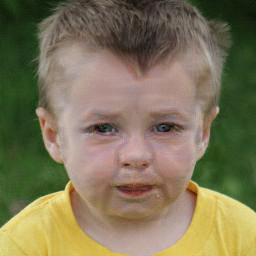

In [11]:
ds[500]["image"]

In [ ]:
ds.push_to_hub("logasja/adversarial_examples_fdf", config_name="lwokey", private=True)